# Mandi Price Forecasting — N-Days-Ahead Modal Price
Dataset: Indian Agricultural Mandi Prices (2023–2025) — Wheat, Tomato, Potato, Onion, Rice

Actual columns in this file: `STATE, District Name, Market Name, Commodity, Variety, Grade,
Min_Price, Max_Price, Modal_Price, Price Date`. Date format is `M/D/Y` (US-style, verified
against the file, not `D/M/Y`). No nulls in any column. Covers 2023-06-06 to 2025-06-11 across
30 states.

**Task**: predict the Modal Price N days ahead, per (Market, Commodity) series.
**Scope**: filtered to `FILTER_STATE` below (default `"Maharashtra"`, matching the APMC use
case this was built for) — set to `None` to train on all-India data instead.
**Split**: time-based (train on earlier dates, test on later dates) — no random shuffling,
since this is a forecasting problem and random splits leak future information into training.
**Primary model**: XGBoost Regressor (falls back to GradientBoostingRegressor if xgboost isn't
installed). Compared against Random Forest, Linear Regression, and a naive persistence baseline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)


## 1. Config

In [2]:
# Adjust these two for your environment / scope
DATA_PATH = "/kaggle/input/datasets/arjunyadav99/indian-agricultural-mandi-prices-20232025/Agriculture_price_dataset.csv"
FILTER_STATE = "Maharashtra"   # set to None to use all-India data
N_DAYS_AHEAD = 7               # forecast horizon


## 2. Load
Tries `DATA_PATH` first (Kaggle environment), then falls back to a local
`Agriculture_price_dataset.csv` in the working directory (e.g. if you
downloaded/uploaded the file directly rather than running inside Kaggle).

In [3]:
import os

candidates = [DATA_PATH, "Agriculture_price_dataset.csv", "./Agriculture_price_dataset.csv"]
path_found = next((p for p in candidates if os.path.exists(p)), None)
if path_found is None:
    raise FileNotFoundError(
        f"Could not find the dataset at any of: {candidates}. "
        "Update DATA_PATH in the Config cell."
    )

df_raw = pd.read_csv(path_found)
print(f"Loaded from: {path_found}")
print(df_raw.shape)
df_raw.head(3)


Loaded from: Agriculture_price_dataset.csv
(737392, 10)


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023


## 3. Clean & Parse
Column names are used exactly as they appear in this file (confirmed via
inspection — no fuzzy matching needed). Renamed here to snake_case for
convenience in the rest of the notebook.

In [4]:
df = df_raw.rename(columns={
    'STATE': 'state',
    'District Name': 'district',
    'Market Name': 'market',
    'Commodity': 'commodity',
    'Variety': 'variety',
    'Grade': 'grade',
    'Min_Price': 'min_price',
    'Max_Price': 'max_price',
    'Modal_Price': 'modal_price',
    'Price Date': 'price_date',
})

# Confirmed format is M/D/Y (0 parse failures vs. 440k+ failures for D/M/Y on this file)
df['price_date'] = pd.to_datetime(df['price_date'], format='%m/%d/%Y', errors='coerce')

for c in ['min_price', 'max_price', 'modal_price']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

before = len(df)
df = df.dropna(subset=['price_date', 'modal_price'])
df = df[df['modal_price'] > 0]
print(f"Dropped {before - len(df)} rows with bad dates/prices, {len(df)} remain")

if FILTER_STATE is not None:
    before = len(df)
    df = df[df['state'].str.strip().str.lower() == FILTER_STATE.strip().lower()]
    print(f"Filtered to state='{FILTER_STATE}': {before} -> {len(df)} rows")

df = df.sort_values(['state', 'market', 'commodity', 'price_date']).reset_index(drop=True)
print(df['price_date'].min(), '->', df['price_date'].max())
df[['state','market','commodity','price_date','modal_price']].head()


Dropped 3 rows with bad dates/prices, 737389 remain


Filtered to state='Maharashtra': 737389 -> 51813 rows
2023-06-06 00:00:00 -> 2025-06-11 00:00:00


,state,market,commodity,price_date,modal_price
0,Maharashtra,Achalpur,Wheat,2023-06-06,2400.0
1,Maharashtra,Achalpur,Wheat,2023-06-07,2350.0
2,Maharashtra,Achalpur,Wheat,2023-06-08,2600.0
3,Maharashtra,Achalpur,Wheat,2023-06-09,2500.0
4,Maharashtra,Achalpur,Wheat,2023-06-13,2250.0


In [5]:
assert len(df) > 0, (
    "No rows left after filtering. If FILTER_STATE is set, check the state name "
    "matches one of: " + str(sorted(df_raw['STATE'].unique()))
)


## 4. Quick EDA
Sanity-check volume per commodity/market before building features on top of
this — a series with too few points won't have enough history for lag/rolling
features to be useful.

In [6]:
print(df['commodity'].value_counts())
print()
print(f"Unique (market, commodity) series: {df.groupby(['market','commodity']).ngroups}")


commodity
Onion     26755
Potato    13518
Wheat      9081
Tomato     1968
Rice        491
Name: count, dtype: int64

Unique (market, commodity) series: 346


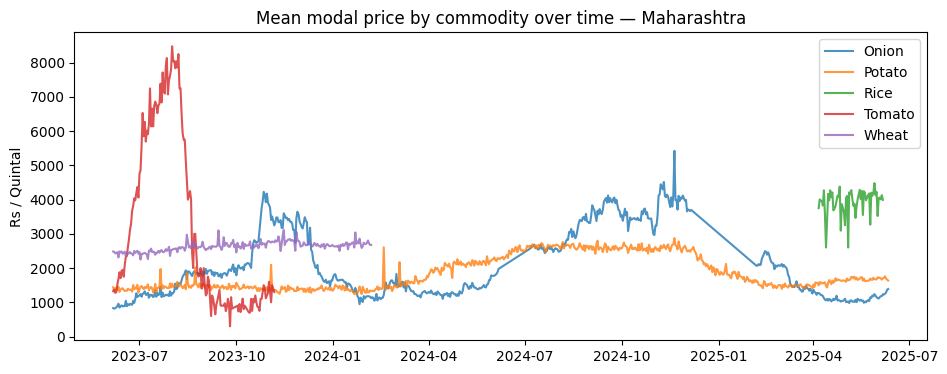

In [7]:
fig, ax = plt.subplots(figsize=(11,4))
for commodity, g in df.groupby('commodity'):
    daily = g.groupby('price_date')['modal_price'].mean()
    ax.plot(daily.index, daily.values, label=commodity, alpha=0.8)
ax.legend()
ax.set_title(f"Mean modal price by commodity over time" + (f" — {FILTER_STATE}" if FILTER_STATE else " — All India"))
ax.set_ylabel('Rs / Quintal')
plt.show()


## 5. Feature Engineering
Each `(market, commodity)` combination is treated as its own time series.
Lags, rolling stats, and calendar features are computed **within each series**
(`groupby` + `shift`) so information never crosses between unrelated markets
or commodities.

**Target**: `modal_price` shifted `N_DAYS_AHEAD` days into the future, within each series.

Note: `Price Date` values are not necessarily daily-consecutive per market
(markets don't report every single day) — lags here are **N reporting-periods
back**, not strictly N calendar days back. That's fine for this model, but
worth knowing if you interpret "7-day lag" literally.


In [8]:
SERIES_KEY = ['state', 'market', 'commodity']

df = df.drop_duplicates(subset=SERIES_KEY + ['price_date'])

g = df.groupby(SERIES_KEY, group_keys=False)

# Lag features: past known prices
for lag in [1, 3, 7, 14]:
    df[f'lag_{lag}'] = g['modal_price'].shift(lag)

# Rolling stats computed on already-lagged data (shift(1) first) to avoid leakage
df['roll_mean_7']  = g['modal_price'].transform(lambda s: s.shift(1).rolling(7).mean())
df['roll_std_7']   = g['modal_price'].transform(lambda s: s.shift(1).rolling(7).std())
df['roll_mean_14'] = g['modal_price'].transform(lambda s: s.shift(1).rolling(14).mean())

# Spread between min/max as a volatility proxy
df['price_range'] = df['max_price'] - df['min_price']

# Calendar features
df['day_of_week'] = df['price_date'].dt.dayofweek
df['month']       = df['price_date'].dt.month
df['day_of_year'] = df['price_date'].dt.dayofyear

# Target: price N reporting-periods ahead, within the same series
df['target'] = df.groupby(SERIES_KEY, group_keys=False)['modal_price'].shift(-N_DAYS_AHEAD)

df.head()


,state,district,market,commodity,variety,grade,min_price,max_price,modal_price,price_date,lag_1,lag_3,lag_7,lag_14,roll_mean_7,roll_std_7,roll_mean_14,price_range,day_of_week,month,day_of_year,target
0,Maharashtra,amarawati,Achalpur,Wheat,Other,FAQ,2300.0,2500.0,2400.0,2023-06-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,1,6,157,2250.0
1,Maharashtra,amarawati,Achalpur,Wheat,Other,FAQ,2200.0,2500.0,2350.0,2023-06-07,2400.0,NaN,NaN,NaN,NaN,NaN,NaN,300.0,2,6,158,2250.0
2,Maharashtra,amarawati,Achalpur,Wheat,Other,FAQ,2200.0,3000.0,2600.0,2023-06-08,2350.0,NaN,NaN,NaN,NaN,NaN,NaN,800.0,3,6,159,2250.0
3,Maharashtra,amarawati,Achalpur,Wheat,Other,FAQ,2400.0,2600.0,2500.0,2023-06-09,2600.0,2400.0,NaN,NaN,NaN,NaN,NaN,200.0,4,6,160,2200.0
4,Maharashtra,amarawati,Achalpur,Wheat,Other,FAQ,2200.0,2300.0,2250.0,2023-06-13,2500.0,2350.0,NaN,NaN,NaN,NaN,NaN,100.0,1,6,164,2250.0


In [9]:
# Encode categoricals for tree models (label encoding is fine for trees;
# they don't assume ordinal meaning the way linear models would)
from sklearn.preprocessing import LabelEncoder

cat_cols = [c for c in ['state', 'district', 'market', 'commodity'] if df[c].nunique() > 1]
# state/district get dropped automatically if FILTER_STATE narrowed to one value —
# a constant column carries zero information and would just add noise.

encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c + '_enc'] = le.fit_transform(df[c].astype(str))
    encoders[c] = le

feature_cols = [c + '_enc' for c in cat_cols] + [
    'lag_1', 'lag_3', 'lag_7', 'lag_14',
    'roll_mean_7', 'roll_std_7', 'roll_mean_14',
    'price_range', 'day_of_week', 'month', 'day_of_year',
    'min_price', 'max_price',
]

model_df = df.dropna(subset=feature_cols + ['target']).reset_index(drop=True)
print(f"{len(model_df)} rows usable after dropping NaNs from lag/target windows")
print(f"Features used: {feature_cols}")


43022 rows usable after dropping NaNs from lag/target windows
Features used: ['district_enc', 'market_enc', 'commodity_enc', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'price_range', 'day_of_week', 'month', 'day_of_year', 'min_price', 'max_price']


In [10]:
assert len(model_df) >= 100, (
    f"Only {len(model_df)} usable rows after feature engineering — too few to train/test "
    "reliably. Try a smaller N_DAYS_AHEAD, fewer/shorter lag windows, or FILTER_STATE=None "
    "for more data."
)


## 6. Time-Based Train/Test Split
Split by a **global date cutoff**, not randomly. Everything before the cutoff
is train, everything after is test — this mirrors how the model will actually
be used (predict the future from the past) and avoids leaking later prices
into training via shared rolling/lag windows.

In [11]:
cutoff = model_df['price_date'].quantile(0.8)
print("Train/test cutoff date:", cutoff.date())

train = model_df[model_df['price_date'] <= cutoff]
test  = model_df[model_df['price_date']  > cutoff]

X_train, y_train = train[feature_cols], train['target']
X_test,  y_test  = test[feature_cols],  test['target']

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

assert len(train) > 0 and len(test) > 0, (
    "Train or test set is empty after the time split — dataset likely too small/narrow "
    "for the 80/20 cutoff. Try FILTER_STATE=None or a smaller N_DAYS_AHEAD."
)


Train/test cutoff date: 2024-11-30
Train: 34417 rows | Test: 8605 rows


## 7. Baselines
Before trusting a fancier model, check it actually beats doing nothing clever.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:22s}  MAE={mae:8.2f}  RMSE={rmse:8.2f}  MAPE={mape:6.2f}%  R2={r2:.3f}")
    return {'model': name, 'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2}

results = []

# Naive persistence: predict that price N periods ahead == today's modal price
naive_pred = test['modal_price']
results.append(report("Naive (persistence)", y_test, naive_pred))


Naive (persistence)     MAE=  247.43  RMSE=  445.53  MAPE= 17.24%  R2=0.531


In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results.append(report("Linear Regression", y_test, lr_pred))


Linear Regression       MAE=  329.96  RMSE=  776.18  MAPE= 24.47%  R2=-0.423


## 8. Main Models: Random Forest & XGBoost
Tree ensembles handle the nonlinear, spiky, seasonal behaviour of mandi prices
(e.g. onion price crashes) far better than linear models, and don't need the
dataset size a neural net would to be worth the added complexity here.

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results.append(report("Random Forest", y_test, rf_pred))


Random Forest           MAE=  299.26  RMSE=  436.66  MAPE= 22.47%  R2=0.550


In [15]:
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    model_name = "XGBoost"
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    xgb = GradientBoostingRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
    )
    model_name = "GradientBoosting (xgboost unavailable)"

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results.append(report(model_name, y_test, xgb_pred))


XGBoost                 MAE=  306.19  RMSE=  432.64  MAPE= 23.57%  R2=0.558


## 9. Compare All Models

In [16]:
results_df = pd.DataFrame(results).sort_values('mae')
results_df


,model,mae,rmse,mape,r2
0,Naive (persistence),247.427262,445.530611,17.239686,0.531043
2,Random Forest,299.259507,436.662026,22.473989,0.549527
3,XGBoost,306.185225,432.637632,23.573586,0.557792
1,Linear Regression,329.959881,776.184261,24.474091,-0.423338


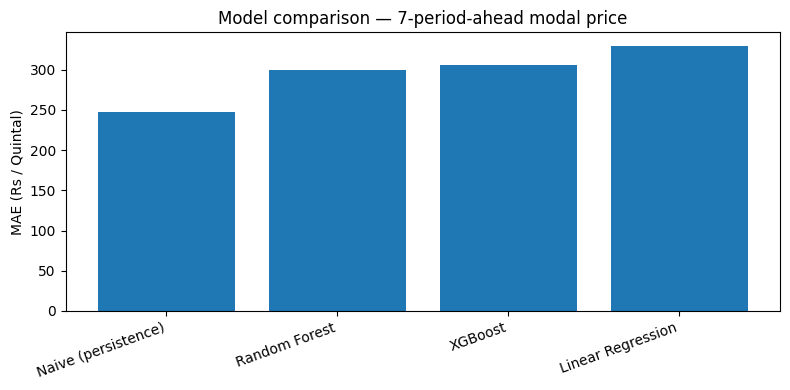

In [17]:
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(results_df['model'], results_df['mae'])
ax.set_ylabel('MAE (Rs / Quintal)')
ax.set_title(f'Model comparison — {N_DAYS_AHEAD}-period-ahead modal price')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 10. Feature Importance (best tree model)
Which signals is the model actually leaning on? If `lag_1` dominates
everything else, the model is mostly just extrapolating the most recent price —
worth knowing before you trust it for a longer horizon.

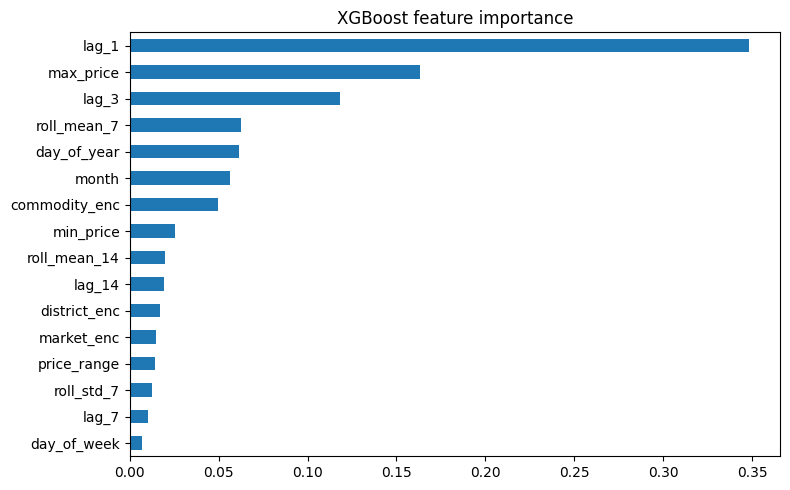

In [18]:
importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
importances.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title(f'{model_name} feature importance')
plt.tight_layout()
plt.show()


## 11. Predicted vs Actual (sanity check on test set)

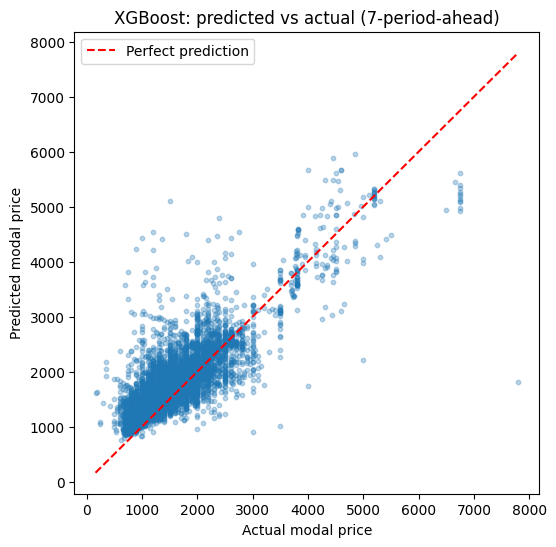

In [19]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_test, xgb_pred, alpha=0.3, s=10)
lims = [min(y_test.min(), xgb_pred.min()), max(y_test.max(), xgb_pred.max())]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Actual modal price')
ax.set_ylabel('Predicted modal price')
ax.set_title(f'{model_name}: predicted vs actual ({N_DAYS_AHEAD}-period-ahead)')
ax.legend()
plt.show()


## 12. Save the Model

In [20]:
import joblib

joblib.dump({
    'model': xgb,
    'encoders': encoders,
    'feature_cols': feature_cols,
    'n_days_ahead': N_DAYS_AHEAD,
    'filter_state': FILTER_STATE,
}, 'mandi_price_model.pkl')

print("Saved to mandi_price_model.pkl")


Saved to mandi_price_model.pkl


## Notes / Next Steps
- **Model used**: primary = XGBoost Regressor (or GradientBoostingRegressor as a fallback),
  compared against Random Forest, Linear Regression, and a naive persistence baseline —
  whichever has the lowest MAE/RMSE in the section 9 table is the one worth keeping.
- The 80/20 time-based split is a single global cutoff. For a more honest error estimate,
  walk-forward validation (rolling-origin cross-validation across multiple cutoff dates)
  would be a stronger next step than trusting one split.
- `N_DAYS_AHEAD` is set to 7 — change it and re-run to see how accuracy degrades as the
  horizon grows (predicting 30 periods out is meaningfully harder than 1).
- `FILTER_STATE = "Maharashtra"` narrows this to APMC markets in-state. Set it to `None`
  to train one model across all 30 states instead — more data, but mixes in
  markets/climates KhetPath likely doesn't need.
- Lags/rolling windows are in **reporting periods**, not strict calendar days, since
  markets don't report every single day. If exact calendar-day gaps matter for your use
  case, that would need explicit date-alignment/resampling per series first.
